In [0]:
# ==========================================
# Import Required Libraries
# ==========================================

from pyspark.sql import functions as F

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

In [0]:
# ==========================================
# Read Cleaned Dataset
# ==========================================

meta_df = spark.read.parquet(
    "/Volumes/project/default/data/clean/meta_clean.parquet"
)

reviews_df = spark.read.parquet(
    "/Volumes/project/default/data/clean/reviews_clean.parquet"
)

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [0]:
combined_df = (
    reviews_df.join(
        meta_df,
        on="parent_asin",
        how="inner"
    )
)

print(f"Total Records : {combined_df.count():,}")

Total Records : 2,105,948


In [0]:
# ==========================================
# Reviews by Year
# ==========================================

year_df = (
    reviews_df
    .groupBy("review_year")
    .count()
    .orderBy("review_year")
)

year_pd = year_df.toPandas()

year_pd

,review_year,count
0,2000,1
1,2002,1
2,2003,8
3,2004,16
4,2005,77
5,2006,180
6,2007,604
7,2008,872
8,2009,1515
9,2010,3500


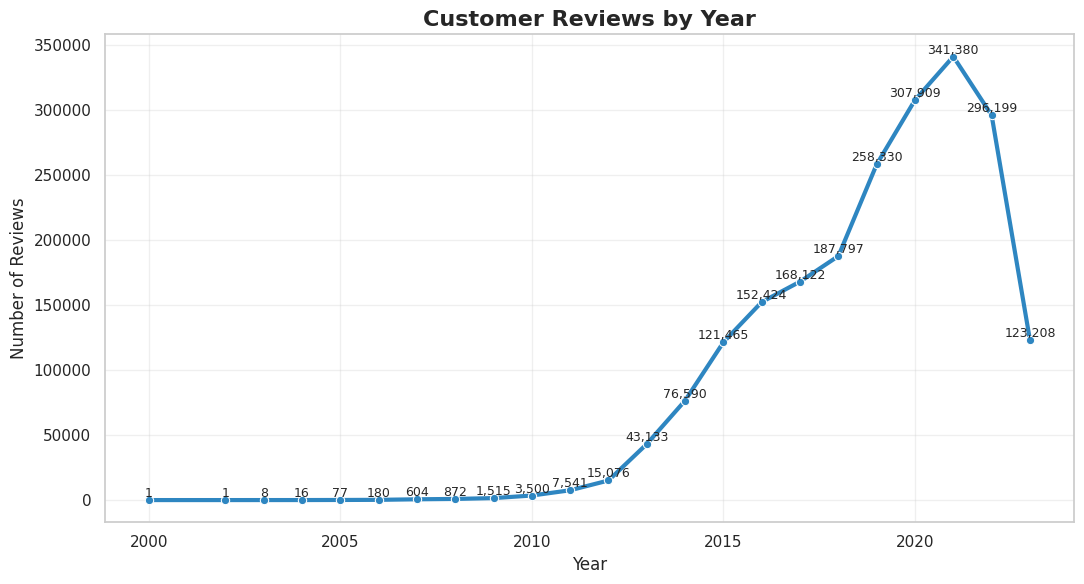

In [0]:
plt.figure(figsize=(11,6))

ax = sns.lineplot(
    data=year_pd,
    x="review_year",
    y="count",
    marker="o",
    linewidth=3,
    color="#2E86C1"
)

# Add value labels
for x, y in zip(year_pd["review_year"], year_pd["count"]):
    plt.text(
        x,
        y,
        f"{y:,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    "Customer Reviews by Year",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Reviews by Month
# ==========================================

month_df = (
    reviews_df
    .groupBy("review_month")
    .count()
    .orderBy("review_month")
)

month_pd = month_df.toPandas()

month_pd

,review_month,count
0,1,212755
1,2,186550
2,3,200919
3,4,168330
4,5,159777
5,6,158102
6,7,178046
7,8,178249
8,9,157030
9,10,159932


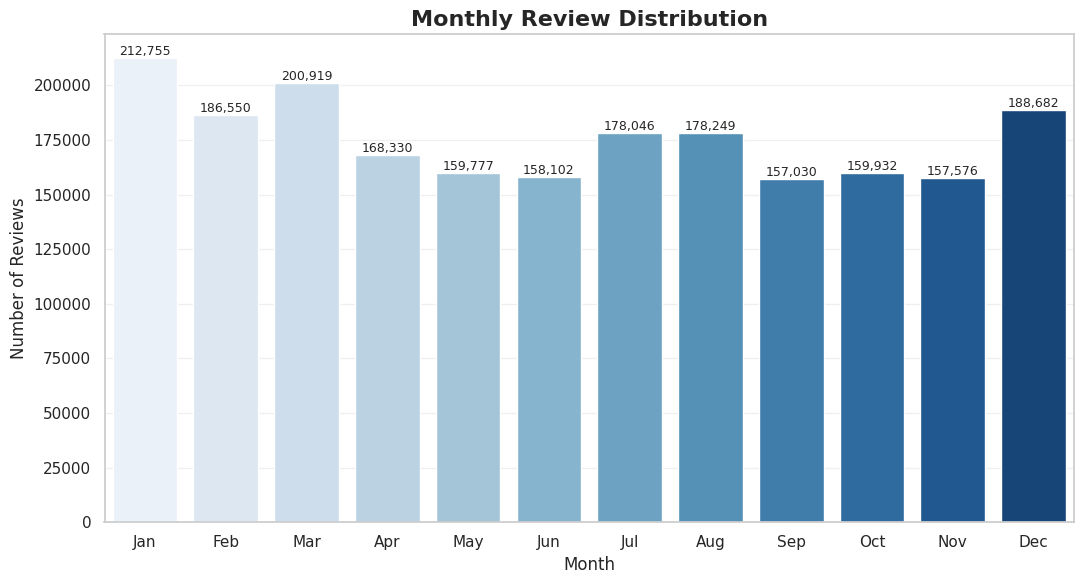

In [0]:
plt.figure(figsize=(11,6))

month_names = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

month_pd["Month"] = month_names

ax = sns.barplot(
    data=month_pd,
    x="Month",
    y="count",
    hue="Month",
    palette="Blues",
    legend=False
)

# Add value labels
for container in ax.containers:
    labels = [
        f"{int(value):,}" if value > 0 else ""
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, fontsize=9)

plt.title(
    "Monthly Review Distribution",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Average Rating by Year
# ==========================================

rating_year = (
    reviews_df
    .groupBy("review_year")
    .agg(
        F.avg("rating").alias("average_rating")
    )
    .orderBy("review_year")
)

rating_year_pd = rating_year.toPandas()

rating_year_pd

,review_year,average_rating
0,2000,4.000000
1,2002,5.000000
2,2003,4.125000
3,2004,3.375000
4,2005,3.363636
5,2006,3.888889
6,2007,3.986755
7,2008,3.892202
8,2009,3.883828
9,2010,3.905429


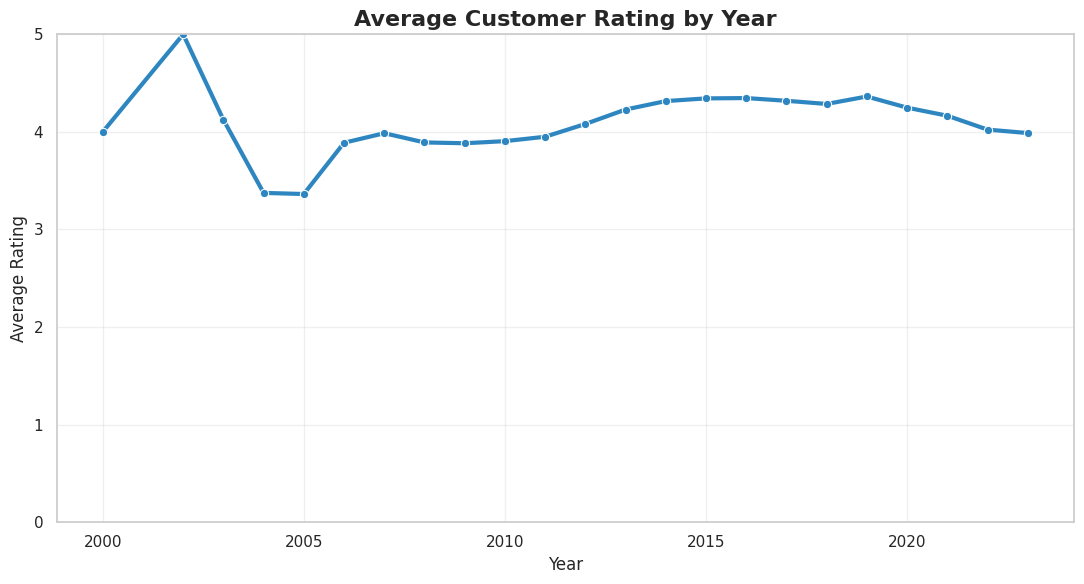

In [0]:
plt.figure(figsize=(11,6))

sns.lineplot(
    data=rating_year_pd,
    x="review_year",
    y="average_rating",
    marker="o",
    linewidth=3,
    color="#2E86C1"
)

plt.title(
    "Average Customer Rating by Year",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.ylim(0,5)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Year-over-Year Growth
# ==========================================

year_pd["Growth (%)"] = (
    year_pd["count"]
    .pct_change() * 100
).round(2)

year_pd

,review_year,count,Growth (%)
0,2000,1,NaN
1,2002,1,0.00
2,2003,8,700.00
3,2004,16,100.00
4,2005,77,381.25
5,2006,180,133.77
6,2007,604,235.56
7,2008,872,44.37
8,2009,1515,73.74
9,2010,3500,131.02


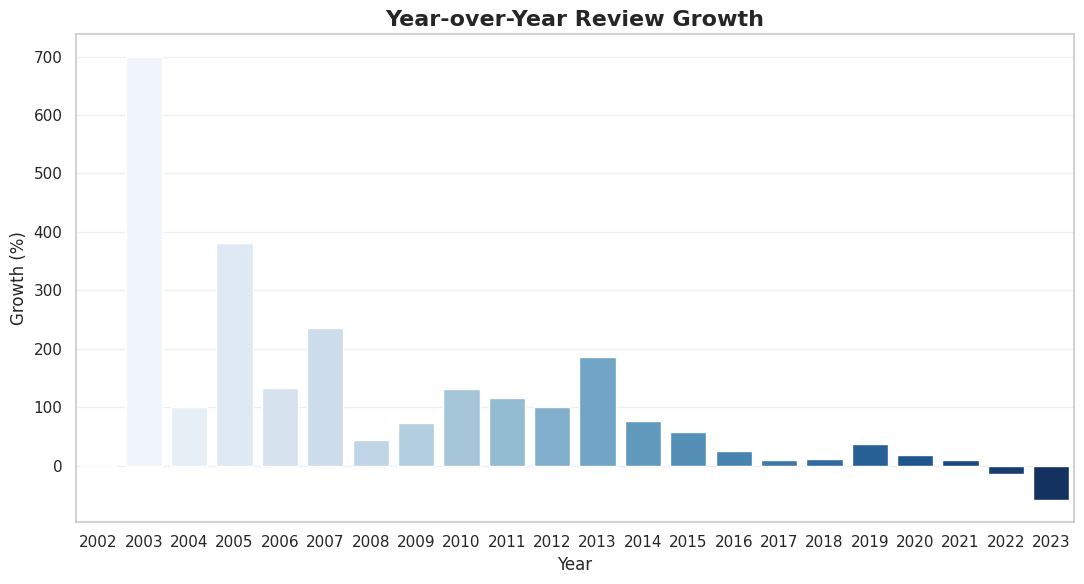

In [0]:
plt.figure(figsize=(11,6))

sns.barplot(
    data=year_pd.dropna(),
    x="review_year",
    y="Growth (%)",
    hue="review_year",
    palette="Blues",
    legend=False
)

plt.title(
    "Year-over-Year Review Growth",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Growth (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Monthly Average Rating
# ==========================================

month_rating = (
    reviews_df
    .groupBy("review_month")
    .agg(
        F.avg("rating").alias("average_rating")
    )
    .orderBy("review_month")
)

month_rating_pd = month_rating.toPandas()

month_rating_pd["Month"] = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

month_rating_pd

,review_month,average_rating,Month
0,1,4.250800,Jan
1,2,4.223865,Feb
2,3,4.220910,Mar
3,4,4.205020,Apr
4,5,4.195141,May
5,6,4.205835,Jun
6,7,4.216809,Jul
7,8,4.221454,Aug
8,9,4.223753,Sep
9,10,4.222582,Oct


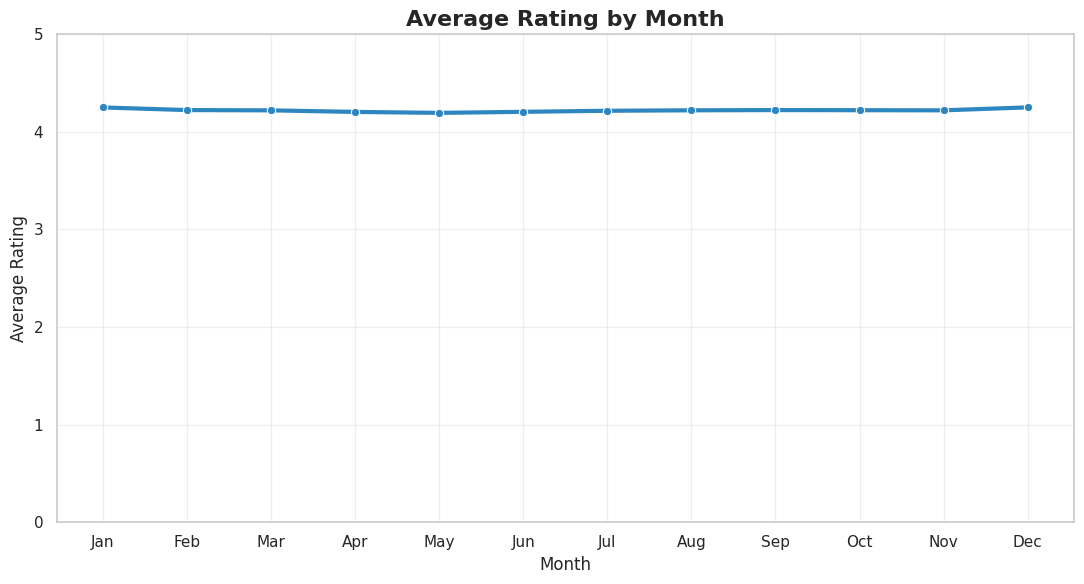

In [0]:
plt.figure(figsize=(11,6))

sns.lineplot(
    data=month_rating_pd,
    x="Month",
    y="average_rating",
    marker="o",
    linewidth=3,
    color="#2E86C1"
)

plt.title(
    "Average Rating by Month",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average Rating")

plt.ylim(0,5)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
heatmap_data = (
    reviews_df
    .groupBy(
        "review_year",
        "review_month"
    )
    .count()
    .toPandas()
)

heatmap = heatmap_data.pivot(
    index="review_year",
    columns="review_month",
    values="count"
)

heatmap

review_month,1,2,3,4,5,6,7,8,9,10,11,12
review_year,,,,,,,,,,,,
2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
2003,1.0,1.0,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,2.0
2004,NaN,NaN,1.0,NaN,NaN,2.0,4.0,2.0,1.0,2.0,3.0,1.0
2005,4.0,3.0,7.0,3.0,10.0,2.0,3.0,7.0,10.0,13.0,11.0,4.0
2006,13.0,24.0,24.0,10.0,5.0,6.0,13.0,16.0,4.0,11.0,33.0,21.0
2007,96.0,40.0,67.0,31.0,58.0,31.0,40.0,42.0,49.0,43.0,36.0,71.0
2008,83.0,81.0,68.0,52.0,60.0,66.0,71.0,74.0,74.0,71.0,77.0,95.0
2009,153.0,128.0,107.0,124.0,98.0,99.0,85.0,118.0,138.0,117.0,158.0,190.0


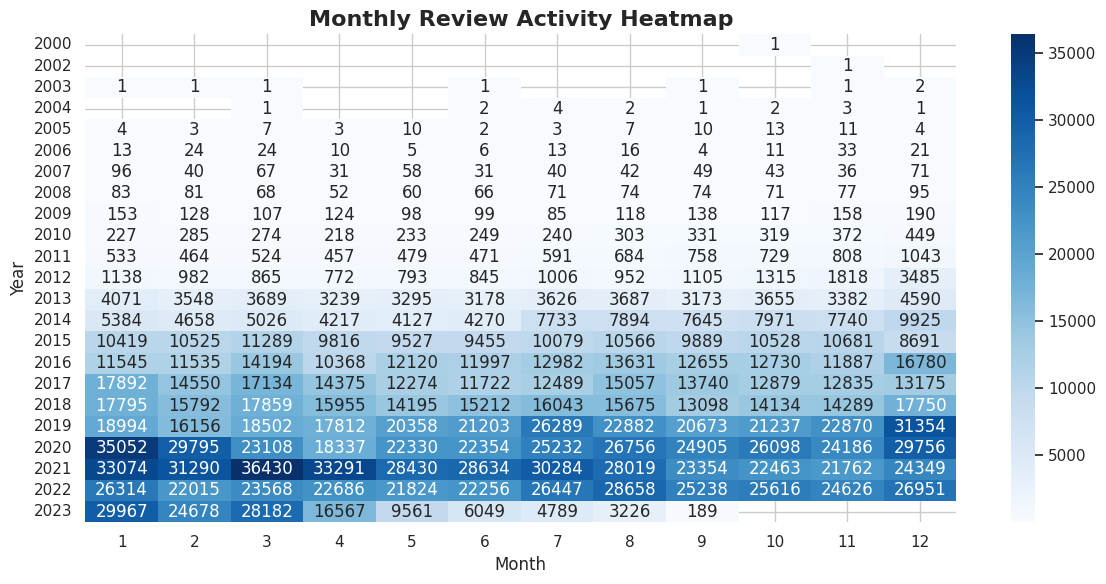

In [0]:
plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap,
    cmap="Blues",
    annot=True,
    fmt=".0f"
)

plt.title(
    "Monthly Review Activity Heatmap",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month")
plt.ylabel("Year")

plt.tight_layout()

plt.show()

# Key Business Insights

- Customer engagement has grown significantly over time.
- Average customer ratings remain consistently high across years and months.
- Seasonal fluctuations primarily affect review volume rather than customer satisfaction.
- Time-based trends provide valuable insights for marketing, inventory planning, and recommendation systems.